
# Headless Volume Rendering in **pygfx**

This notebook follows the API patterns shown in the IDA workshop tutorial for Pygfx (Texture with `dim=3`, `Geometry(grid=...)`, `VolumeRayMaterial`/`VolumeIsoMaterial`) and adapts them for **headless/offscreen** rendering using an offscreen WGPU canvas and `renderer.snapshot()`.



## 0) Environment & Requirements

- Python 3.9+
- `pygfx`, `wgpu`, `numpy`, `imageio[v3]`, `tifffile` (for TIFF), `zarr`/`ome-zarr` (optional)

**Install (uncomment as needed):**
```bash
# pip
# pip install pygfx wgpu numpy imageio[ffmpeg] tifffile zarr ome-zarr dask

# conda-forge
# mamba install -c conda-forge pygfx wgpu numpy imageio tifffile zarr ome-zarr dask ffmpeg
```

**Headless backend** (Linux/CI): ensure a WGPU backend is available (Vulkan/Metal/DX12). On Linux CI, `mesa-vulkan-drivers` often works. If needed, force Vulkan:
```python
import os
os.environ.setdefault("WGPU_BACKEND_TYPE", "VULKAN")
```
Set the env *before* importing `wgpu/pygfx`.


In [21]:

# 1) Imports & optional backend override
import os
# Uncomment if your CI needs it:
# os.environ.setdefault("WGPU_BACKEND_TYPE", "VULKAN")

import numpy as np
import imageio.v3 as iio
from pathlib import Path
import tifffile as tiff
import matplotlib.pyplot as plt

import pygfx as gfx
import wgpu
from wgpu.gui.offscreen import WgpuCanvas

print("pygfx:", gfx.__version__)
print("wgpu:", wgpu.__version__)

OUT = Path("pygfx_headless_outputs"); OUT.mkdir(exist_ok=True, parents=True)


pygfx: 0.15.0
wgpu: 0.25.0



## 2) Load example data


In [25]:
vol = tiff.imread(Path("example_data") / "size_512" / "raw_channel3.tif")
vol.min(), vol.max(), vol.shape, vol.dtype


(np.float32(0.0), np.float32(255.0), (512, 512, 512), dtype('float32'))


## 3) Offscreen canvas, renderer, scene, camera

Use `WgpuCanvas(size=...)` for an offscreen target. We position the camera and then fit it to the object using `camera.show_object(...)` like in the tutorial.


In [26]:

# Offscreen rendering setup (no GUI window)
canvas = WgpuCanvas(size=(1024, 768))
renderer = gfx.renderers.WgpuRenderer(canvas)

scene = gfx.Scene()
camera = gfx.PerspectiveCamera(70, 1024/768)

# A bit of ambient light helps when materials use shading (isosurface)
scene.add(gfx.AmbientLight(intensity=0.8))
scene.add(gfx.DirectionalLight())

def fit_camera_to_scene(cam, obj_or_scene, view_dir=(-1, -1, -1), up=(0, 0, 1), scale=1.2):
    cam.show_object(obj_or_scene, view_dir=view_dir, up=up, scale=scale)

print("Renderer/scene ready.")


Renderer/scene ready.



## 4) Raycasting volume (as in the workshop page)

Follow the **same construction** as the workshop code: `Texture(vol, dim=3)`, wrap with `Geometry(grid=tex)`, then `VolumeRayMaterial(...)` and `Volume(...)`.


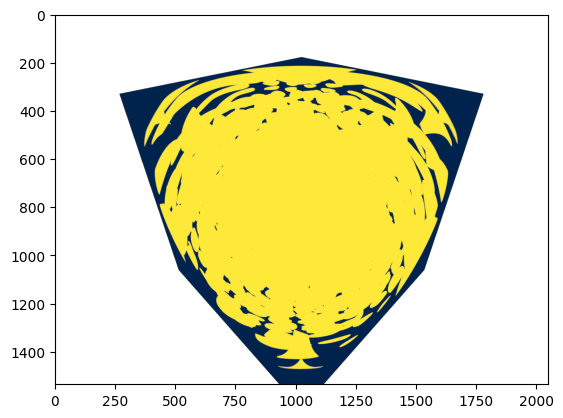

In [30]:

# Texture uses the tutorial's signature: dim=3 (not dims="3D")
tex = gfx.Texture(vol, dim=3)
ray_vol = gfx.Volume(
    gfx.Geometry(grid=tex),
    gfx.VolumeRayMaterial(clim=(0.0, 255.0), map=gfx.cm.cividis, pick_write=True),
)
scene.add(ray_vol)
fit_camera_to_scene(camera, scene)

# Render & snapshot
renderer.render(scene, camera)

plt.imshow(renderer.snapshot())


## 5) Isosurface volume (same API as tutorial)

Create a second volume using `VolumeIsoMaterial(threshold=...)`. Use a clear threshold like `0.5` for our normalized data.


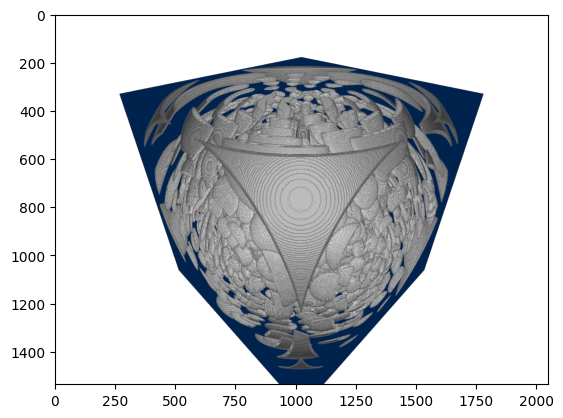

In [31]:

iso_geom = gfx.Geometry(grid=vol)  # Geometry can take a numpy grid directly
iso_mat = gfx.VolumeIsoMaterial(clim=(0.0, 1.0), threshold=0.5)
iso_vol = gfx.Volume(iso_geom, iso_mat)
scene.add(iso_vol)

fit_camera_to_scene(camera, scene)
renderer.render(scene, camera)

plt.imshow(renderer.snapshot())


## 6) Switching methods on the ray material (mip/ray/iso) when available

If your `VolumeRayMaterial` exposes `method`, you can switch to `'mip'` or `'iso'`. We guard with `hasattr` for version compatibility.


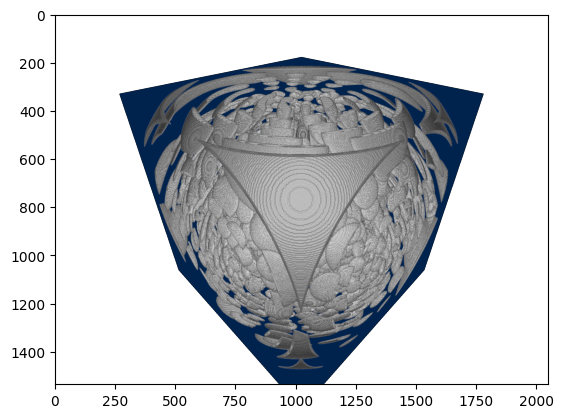

In [32]:

def set_if_has(obj, name, value):
    if hasattr(obj, name):
        try:
            setattr(obj, name, value)
        except Exception:
            pass

set_if_has(ray_vol.material, "method", "mip")
renderer.render(scene, camera)
plt.imshow(renderer.snapshot())


set_if_has(ray_vol.material, "method", "ray")
renderer.render(scene, camera)

plt.imshow(renderer.snapshot())


## 8) Spin animation (GIF/MP4)


In [33]:

frames = []
for az in np.linspace(0, 360, 90, endpoint=False):
    orbit_camera(camera, elev_deg=30, azim_deg=float(az))
    renderer.render(scene, camera)
    frames.append(renderer.snapshot())

mp4_path = OUT / "spin.mp4"
try:
    iio.imwrite(mp4_path, frames, fps=20)
except Exception as e:
    print("MP4 export failed (likely missing ffmpeg). GIF saved.", e)

from IPython.display import Video
Video(mp4_path, width=800)